In [26]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("/content/Advertising.csv")
df.drop("Unnamed: 0",axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


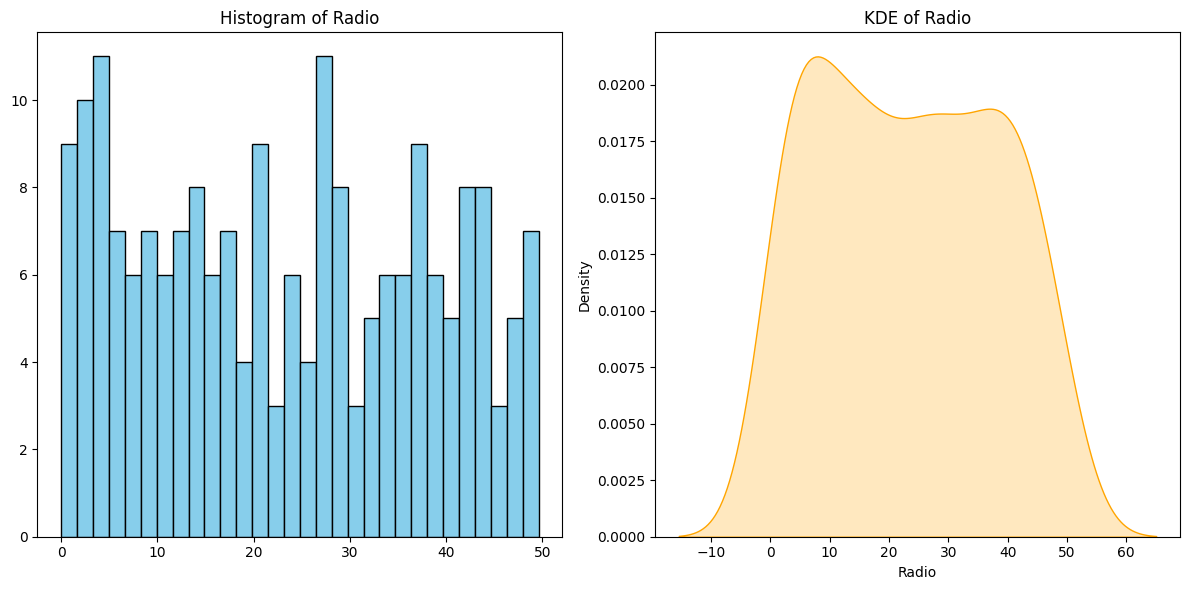

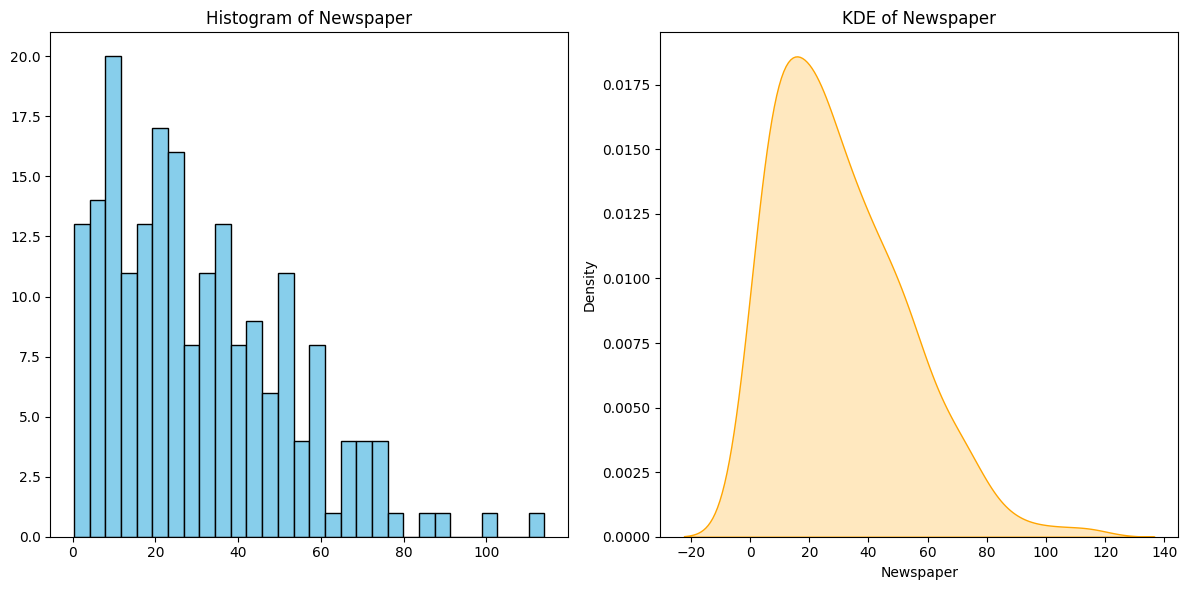

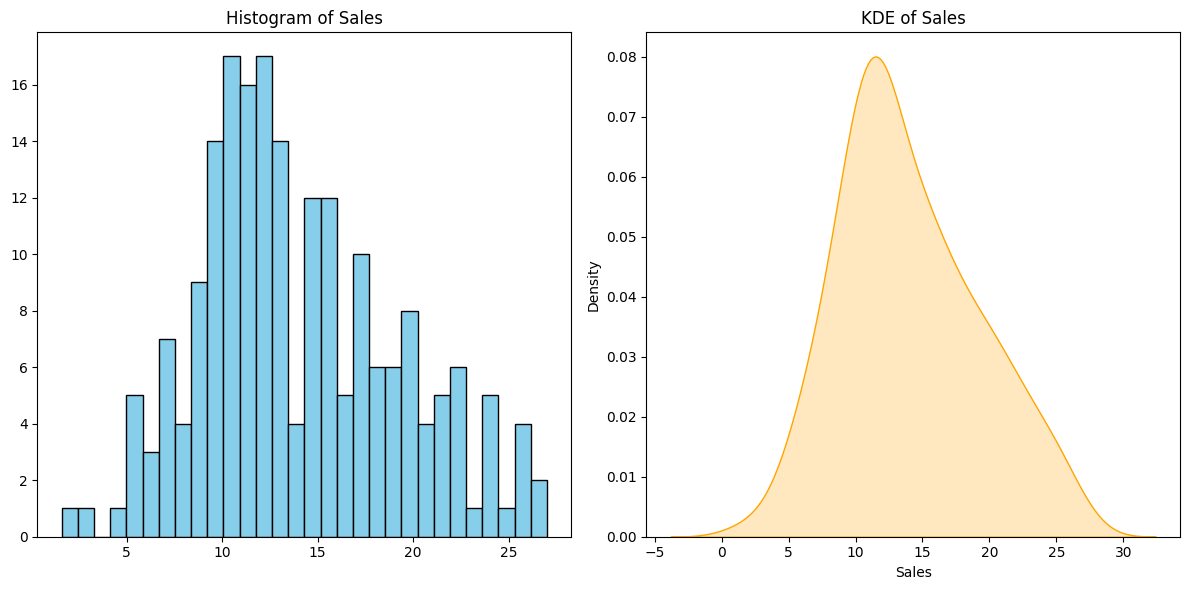

In [27]:
cols = df.columns
for i in cols[1:]:
    plt.figure(figsize=(12,6))
    plt.subplot(1, 2, 1)
    plt.hist(df[i], bins=30, color='skyblue' , edgecolor='black')
    plt.title(f'Histogram of {i}')

    plt.subplot(1, 2, 2)
    sns.kdeplot(df[i], color='orange' , fill=True)
    plt.title(f'KDE of {i}')

    plt.tight_layout()
    plt.show()

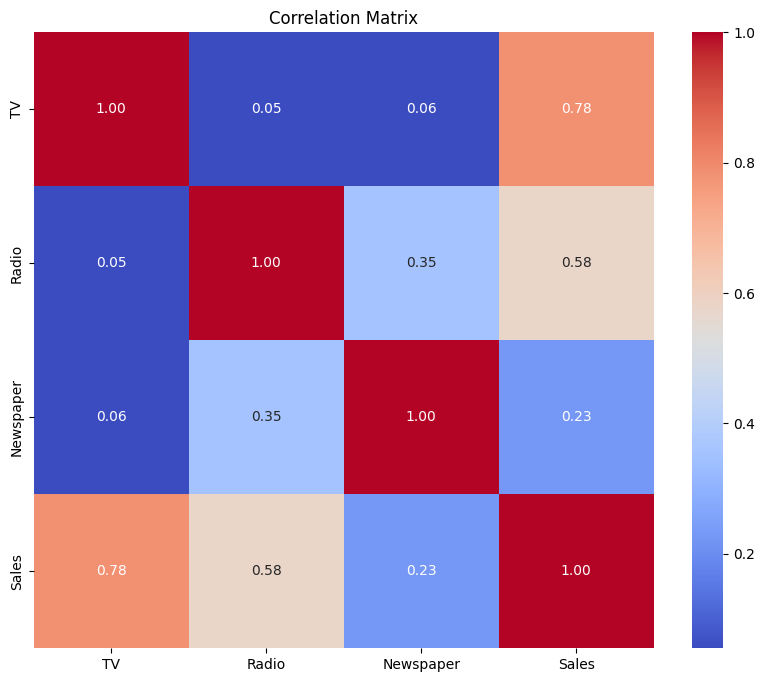

In [28]:
corr = df[cols[:]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Model Training with XGBoost

In [29]:
# Separate features (X) and target (y)
X = df.drop('Sales', axis=1)
y = df['Sales']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


### Feature Scaling
We'll use `StandardScaler` to scale the features. Although tree-based models like XGBoost are not sensitive to feature scaling, it's a good practice, especially if we consider other models later.

In [30]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names (optional, for better readability)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Scaled X_train (first 5 rows):")
display(X_train_scaled_df.head())
print("Scaled X_test (first 5 rows):")
display(X_test_scaled_df.head())

Scaled X_train (first 5 rows):


,TV,Radio,Newspaper
79,-0.404248,-1.028237,-0.337675
197,0.320608,-0.919828,-1.161439
38,-1.270511,0.259124,0.254251
24,-1.042359,-0.696233,-0.574446
122,0.879103,-1.387343,-0.707629


Scaled X_test (first 5 rows):


,TV,Radio,Newspaper
95,0.157812,0.591127,1.132275
15,0.539253,1.681996,1.132275
30,1.697834,0.367533,0.653801
158,-1.643633,0.950233,0.752455
128,0.835137,1.770079,-1.319286


In [31]:
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


### Model Evaluation
Let's evaluate the trained model's performance on the test set using various metrics.

Mean Squared Error (MSE): 0.7794
Mean Absolute Error (MAE): 0.6833
R-squared (R2): 0.9753


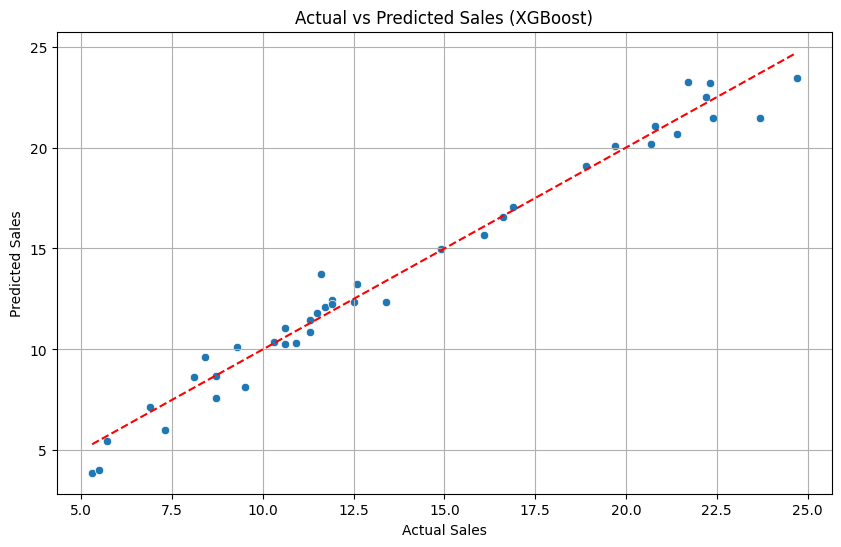

In [32]:
# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (XGBoost)')
plt.grid(True)
plt.show()